#### imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import functions
importlib.reload(functions)
from functions import *

import NN_layers
importlib.reload(NN_layers)
from NN_layers import *

import torch 
import torch.nn as nn
import torch.nn.functional  as F

from torch import Tensor
from torchvision import transforms

import pandas as pd
import PIL.Image as Image

import kagglehub

c:\Users\katin\Lokale_dokumenter\Fagprojekt---Group-Equivariance\fag_projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("zalando-research/fashionmnist")

In [3]:
n = 50
basis, radius_map = functions.fourier_basis(n,4,plot = False)

In [4]:
ll = LiftingLayer(in_features = 10, out_features = 10, kernel_size = 5, l = 3)

# MNIST


In [5]:
#Laver vores MNIST image
RESIZE_SIZE = 28

df = pd.read_csv(path + '/fashion-mnist_train.csv')
row1 = df.iloc[0, 1:].values
pixel = row1.reshape(28,28).astype(np.uint8)

img = Image.fromarray(pixel)

transform = transforms.ToTensor()

img = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.NEAREST)

image = transform(img)
image = image.unsqueeze_(0).to(torch.complex128)

In [6]:
num_images = 1000
df_train = df[:num_images]

# Split labels og pixels
labels = df_train.iloc[:, 0].values            # første kolonne = label
pixels = df_train.iloc[:, 1:].values           # resten = 784 pixels per række

# Til tensor + reshape til (N, C, H, W)
images = torch.tensor(pixels, dtype=torch.float32) / 255.0   # normaliser [0,1]
images = images.reshape(-1, 1, 28, 28)         # (1000, 1, 28, 28)

labels = torch.tensor(labels, dtype=torch.long)

print(images.shape)  # torch.Size([1000, 1, 28, 28])
print(labels.shape)  # torch.Size([1000])

torch.Size([1000, 1, 28, 28])
torch.Size([1000])


<class 'numpy.ndarray'>


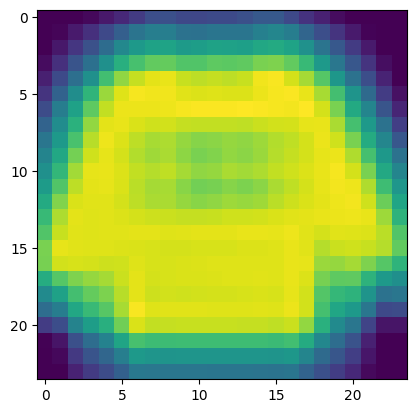

In [7]:
image.shape

out = ll.forward(image) # 
out[0][7].shape

putput = out[0][4].detach().numpy()
amps = np.abs(putput)
print(type(putput))
plt.imshow(amps)

## Convolutions

Test of how complicated functions MLP_radius can fit

In [8]:
if False:
    x = (np.linspace(-2.5 *np.pi ,2.5*np.pi,100))
    x = np.random.permutation(x)

    x = torch.tensor(x).float().unsqueeze_(1)
    print(x.shape)
    y = np.sin(x)
    y = torch.tensor(y)
    model = MLP_Radius(bias = True, hidden_units=100, depth = 2)
    MLP_Radius
    criterion = nn.MSELoss()

    # optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # training loop
    epochs = 50000


    for epoch in range(epochs):
        optimizer.zero_grad()

        # forward pass
        outputs = model(x)

        # compute loss
        loss = criterion(outputs, y)

        # backward pass
        loss.backward()

        # update weights
        optimizer.step()
        
        # if epoch % 10 == 0:
        #     print(f"epoch {epoch}, loss = {loss.item():.4f}")
    output = model.forward(x)

    output = torch.detach(output)
    plt.scatter(x, output.numpy())
    plt.scatter(x , y.numpy())

# Training the model

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

model = LiftingLayer(in_features=1,out_features= 10,kernel_size= 5,l =3)


criterion = nn.MSELoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# training loop
epochs = 5

for epoch in range(epochs):
    optimizer.zero_grad()

    #insæt batch??
    
    # forward pass
    outputs = model(images)

    # compute loss
    loss = criterion(outputs, labels)

    # backward pass
    loss.backward()

    # update weights
    optimizer.step()
    
    # if epoch % 10 == 0:
    #     print(f"epoch {epoch}, loss = {loss.item():.4f}")
x = #indsæt billede(r)
output = model.forward(x)

RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

: 

: 

: 

: 

## Ækvivarians-test (skal slettes)

Tester om laget er ækvivariant: $\Phi(R \cdot x) \stackrel{?}{=} R \cdot \Phi(x)$.

**Bemærk:** Ækvivarians er en strukturel egenskab af arkitekturen — den er der eller den er der ikke. Ingen træning nødvendig.

Den øverste række (rotér input → Φ) skal ligne den nederste række (Φ → rotér output). Numerisk fejl skal være tæt på 0 for vinkler der er multipler af 90° (ingen interpolations-støj). Ved 45°/135° er der altid en lille fejl pga. bilinær rotation.

Vi viser **magnitude** (`|·|`) af output for at undgå at skulle vælge real- eller imag-del separat for komplekse outputs.

Layer accepterer dtype: torch.complex128
Angle=  0°  equivariance error = 0.000000
Angle= 45°  equivariance error = 0.461057
Angle= 90°  equivariance error = 0.536884
Angle=135°  equivariance error = 0.588699
Angle=180°  equivariance error = 0.506556


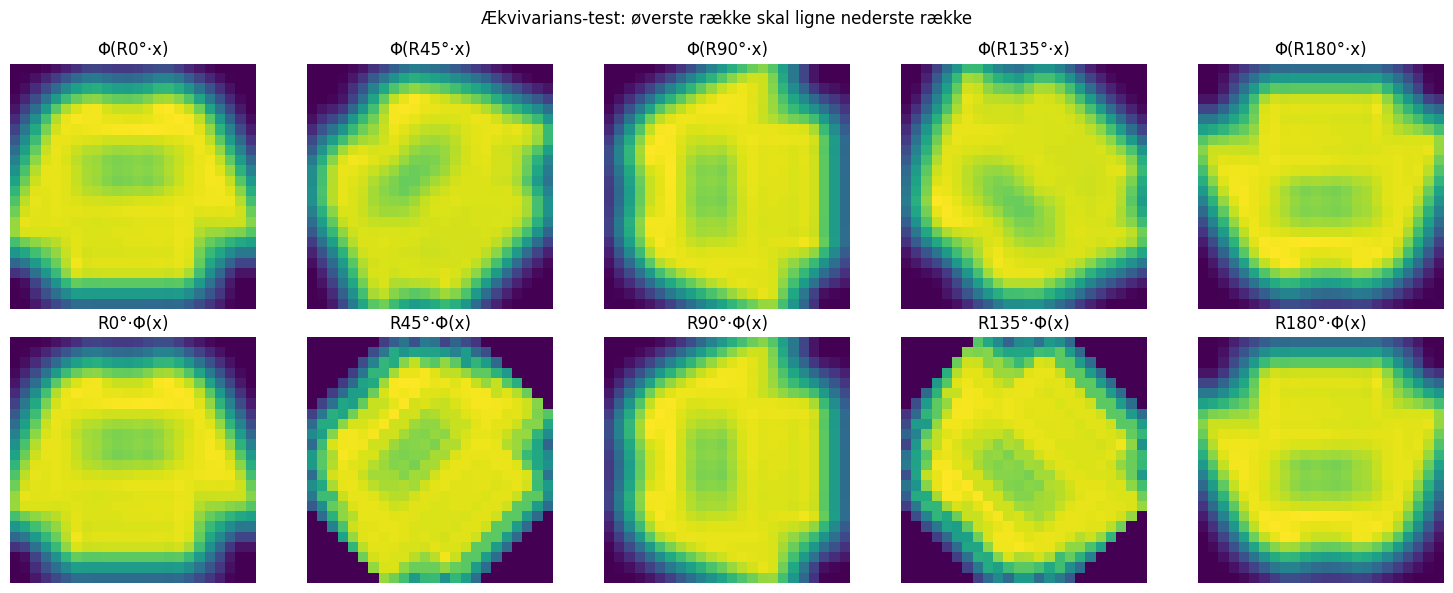

: 

: 

: 

: 

In [ ]:
import torchvision.transforms.functional as TF

# --- Helper: TF.rotate kan ikke håndtere complex tensors direkte;
#     vi roterer real og imag separat hvis input er complex ---
def rotate_any(x, angle):
    if x.is_complex():
        return torch.complex(TF.rotate(x.real, angle), TF.rotate(x.imag, angle))
    return TF.rotate(x, angle)

# --- Helper: detekter hvilken dtype LiftingLayer faktisk accepterer ---
def detect_layer_dtype(layer, sample):
    for dt in (torch.complex128, torch.complex64, torch.float32):
        try:
            with torch.no_grad():
                _ = layer(sample.to(dt))
            return dt
        except Exception:
            continue
    raise RuntimeError('Ingen af de afprøvede dtypes virker for dette lag')

INPUT_DTYPE = detect_layer_dtype(ll, images[0:1])
print(f'Layer accepterer dtype: {INPUT_DTYPE}')

# --- Vælg test-billede med korrekt dtype ---
test_image = images[0:1].to(INPUT_DTYPE)

# --- Vinkler at teste ---
angles = [0, 45, 90, 135, 180]

ll.eval()
with torch.no_grad():
    # Beregn Φ(x) én gang udenfor løkken
    out_unrot = ll(test_image)

    fig, axes = plt.subplots(2, len(angles), figsize=(3*len(angles), 6))

    for k, angle in enumerate(angles):
        # Vej 1: rotér INPUT først, så Φ
        rotated_input = rotate_any(test_image, angle).to(INPUT_DTYPE)
        out_rot_then_phi = ll(rotated_input)

        # Vej 2: Φ først, så rotér OUTPUT
        out_phi_then_rot = rotate_any(out_unrot, angle)

        # Numerisk forskel — på magnitude (virker for både real og complex)
        err = (out_rot_then_phi - out_phi_then_rot).abs().mean().item()
        print(f'Angle={angle:3d}°  equivariance error = {err:.6f}')

        # Plot magnitude af kanal 0
        img1 = out_rot_then_phi[0, 0].abs().detach().numpy()
        img2 = out_phi_then_rot[0, 0].abs().detach().numpy()

        axes[0, k].imshow(img1)
        axes[0, k].set_title(f'Φ(R{angle}°·x)')
        axes[0, k].axis('off')

        axes[1, k].imshow(img2)
        axes[1, k].set_title(f'R{angle}°·Φ(x)')
        axes[1, k].axis('off')

    plt.suptitle('Ækvivarians-test: øverste række skal ligne nederste række')
    plt.tight_layout()
    plt.show()